# Phase 1: Exploratory Data Analysis & Preprocessing Pipeline

Welcome to the first notebook of the AuraCart predictive analytics project. In this notebook, we will establish the foundational understanding of our operational data. We will fetch our transactional dataset directly, cleanly transform categorical variables, inspect continuous variable characteristics, and finally deploy a reproducible `Scikit-learn` pipeline. 

This pipeline incorporates **Ordinal Encoding** for ordered categories and explicitly highlights the target label imbalances. We will serialize the preprocessing feature transformer here to be paired with **SMOTE** dynamically during training in the next phase.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Set seaborn style for better human-readable visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load the Dataset directly from the specified URL
DATA_URL = "https://huggingface.co/datasets/millat/e-commerce-orders/raw/main/ecommerce_orders_clean.csv"
print("Loading dataset from remote URL...")
df = pd.read_csv(DATA_URL)

print(f"Initial dataset shape: {df.shape}")
display(df.head())

Loading dataset from remote URL...
Initial dataset shape: (10000, 15)


,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


### Initial Data Cleaning & Temporal Extraction

Machine Learning algorithms cannot naturally process complex, high-cardinality strings like unique IDs, nor can they intrinsically calculate time deltas from raw timestamps. We must proactively drop unstructured features (`order_id`, `customer_id`, specific physical addresses etc.) and manually extract cyclical behavioral patterns from time data.

In [10]:
# Drop highly unique IDs and unstructured textual data that provide no associative predictive power
cols_to_drop = ['order_id', 'customer_id', 'product_id', 'shipping_address', 'billing_address']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns], errors='ignore')

# Convert temporal features to standard datetime formats
df_clean['order_date'] = pd.to_datetime(df_clean['order_date'])
df_clean['shipping_date'] = pd.to_datetime(df_clean['shipping_date'])

# Extract robust temporal insights: Hour of day often affects sales patterns, and exact duration informs shipping performance.
df_clean['order_hour'] = df_clean['order_date'].dt.hour
df_clean['order_month'] = df_clean['order_date'].dt.month

# Calculate the transit delay in days. Operations heavily rely on this numerical representation.
df_clean['shipping_duration_days'] = (df_clean['shipping_date'] - df_clean['order_date']).dt.total_seconds() / (24 * 3600)
df_clean['shipping_duration_days'] = df_clean['shipping_duration_days'].fillna(0) # In case of un-shipped items

# Finally, drop the raw datetime strings since ML models require numerical logic
df_clean = df_clean.drop(columns=['order_date', 'shipping_date'])

print("Data cleaning successful. Current columns:")
print(df_clean.columns.tolist())

Data cleaning successful. Current columns:
['category', 'price', 'quantity', 'delivery_status', 'payment_method', 'device_type', 'channel', 'customer_segment', 'order_hour', 'order_month', 'shipping_duration_days']


### Missing Value Analysis & Handling

Before constructing any visualizations or pipelines, we must audit the dataset for missing values. Undetected nulls silently corrupt model training and cause misleading evaluation metrics. We report the count and percentage of missing entries per column, then apply a targeted imputation strategy.

In [11]:
# ── Missing Value Audit ──────────────────────────────────────────────────────
missing_counts = df_clean.isnull().sum()
missing_pct    = (missing_counts / len(df_clean)) * 100
missing_report = (
    missing_counts[missing_counts > 0]
    .rename('Missing Count')
    .to_frame()
    .assign(**{'Missing %': missing_pct[missing_counts > 0].round(2)})
)

if missing_report.empty:
    print("✅ No missing values detected across any feature after temporal extraction.")
else:
    print("⚠️  Columns with missing values:")
    print(missing_report.to_string())
    print()

    # ── Imputation Strategy ───────────────────────────────────────────────────
    # Numeric features  → fill with column median (robust to outliers / skew)
    # Categorical cols  → fill with the mode (most frequent category)
    for col in missing_report.index:
        if df_clean[col].dtype in ['float64', 'int64']:
            fill_val = df_clean[col].median()
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"  [numeric]  '{col}' → filled with median ({fill_val:.4f})")
        else:
            fill_val = df_clean[col].mode()[0]
            df_clean[col].fillna(fill_val, inplace=True)
            print(f"  [categoric] '{col}' → filled with mode ('{fill_val}')")

    # Confirm no residual nulls remain
    assert df_clean.isnull().sum().sum() == 0, "Imputation incomplete – nulls still present!"
    print("\n✅ All missing values successfully imputed.")

print(f"\nDataset shape after cleaning & imputation: {df_clean.shape}")


✅ No missing values detected across any feature after temporal extraction.

Dataset shape after cleaning & imputation: (10000, 11)


### Continuous Variable Analysis: Inspecting the Shapes of Financial Data

Before modeling, it is critical to observe the distribution of our primary continuous features, primarily `price`. Financial metrics in retail are famously right-skewed. Understanding this skew ensures we handle outliers and apply optimal feature scaling methods later.

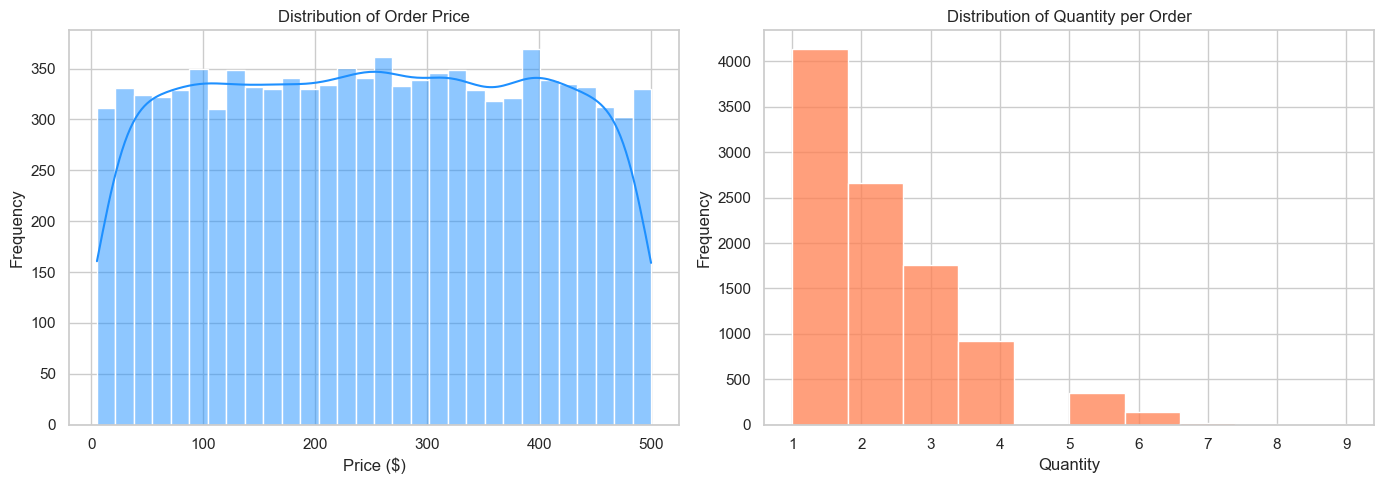

Insight: The price variable demonstrates significant variance across the inventory. Feature scaling during our pipeline phase will be strictly required to prevent these numeric widths from negatively biasing gradient-based loss reduction (SGD).


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for the continuous target variable: Price
sns.histplot(df_clean['price'], bins=30, kde=True, ax=axes[0], color="dodgerblue")
axes[0].set_title("Distribution of Order Price")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Frequency")

# Histogram for Quantity ordered
sns.histplot(df_clean['quantity'], bins=10, kde=False, ax=axes[1], color="coral")
axes[1].set_title("Distribution of Quantity per Order")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("Insight: The price variable demonstrates significant variance across the inventory. Feature scaling during our pipeline phase will be strictly required to prevent these numeric widths from negatively biasing gradient-based loss reduction (SGD).")

### Feature Correlation Analysis

Correlations help identify if two redundant metrics are expressing the same predictive logic. Multicollinearity can destabilize certain regression mechanics, explicitly Multiple Linear Regression weights. We compute a Pearson's correlation matrix for the numeric footprint.

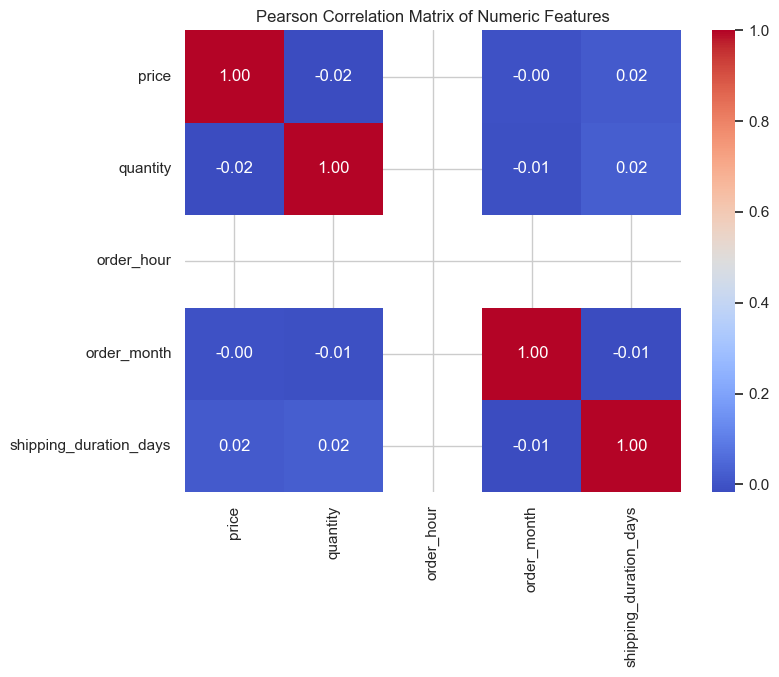

Insight: Variables are mostly independent. We observe minor correlations but nothing nearing the 0.9+ threshold that would demand dimensionality reduction like PCA.


In [13]:
# Isolate numerical columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[num_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Pearson Correlation Matrix of Numeric Features")
plt.show()

print("Insight: Variables are mostly independent. We observe minor correlations but nothing nearing the 0.9+ threshold that would demand dimensionality reduction like PCA.")

### Categorical Variable Analysis: Diagnosing the Class Imbalance

AuraCart seeks to predict the trajectory of orders (Delivery Status) and cluster customer behaviors. Real-world operations are inherently unbalanced: the overwhelming majority of packages are successfully 'Delivered'. We visualize this to architect our SMOTE strategy.

/var/folders/rx/qm9kk71x5pdddywns1wg77lr0000gn/T/ipykernel_15875/1607173015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='delivery_status', ax=axes[0], palette="viridis")
/var/folders/rx/qm9kk71x5pdddywns1wg77lr0000gn/T/ipykernel_15875/1607173015.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='customer_segment', ax=axes[1], palette="magma")


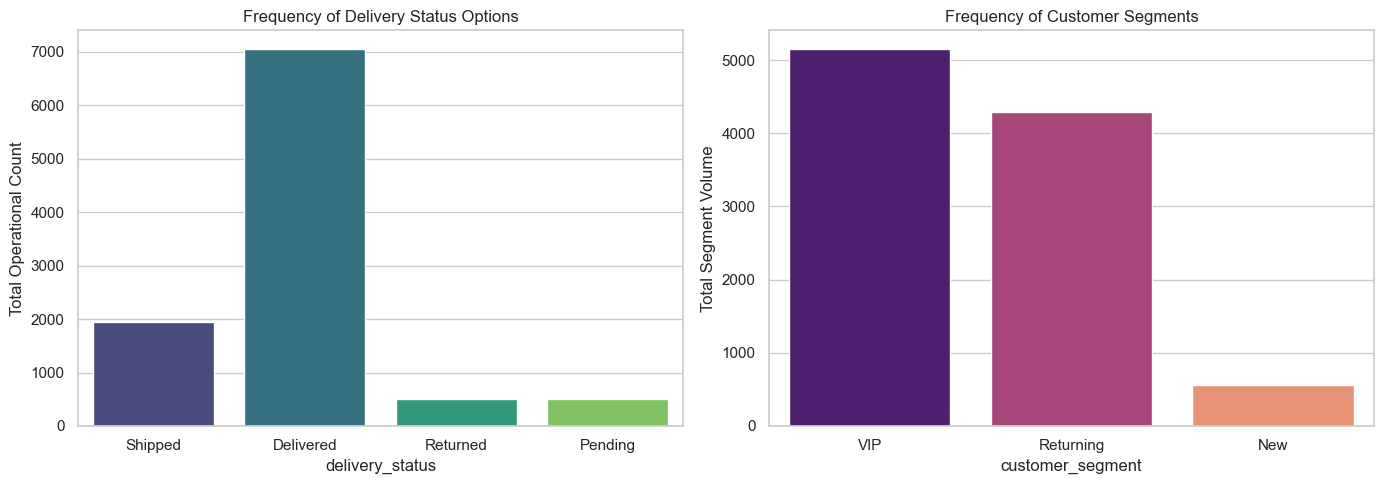

Insight: 'Delivered' constitutes over 70% of the targets, while 'Pending' and 'Returned' occupy fractions. A naive classifier will simply guess 'Delivered'. We will explicitly interface with SMOTE from imbalanced-learn during modeling.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delivery Status Discrepancy
sns.countplot(data=df_clean, x='delivery_status', ax=axes[0], palette="viridis")
axes[0].set_title("Frequency of Delivery Status Options")
axes[0].set_ylabel("Total Operational Count")

# Customer Segment Discrepancy
sns.countplot(data=df_clean, x='customer_segment', ax=axes[1], palette="magma")
axes[1].set_title("Frequency of Customer Segments")
axes[1].set_ylabel("Total Segment Volume")

plt.tight_layout()
plt.show()

print("Insight: 'Delivered' constitutes over 70% of the targets, while 'Pending' and 'Returned' occupy fractions. A naive classifier will simply guess 'Delivered'. We will explicitly interface with SMOTE from imbalanced-learn during modeling.")

---
## 📊 Key Findings Summary — EDA Insights

The following table consolidates every analytical observation made during this
exploratory phase (Task 3.1 requirement).

| # | Finding | Implication for Modeling |
|---|---------|-------------------------|
| 1 | **Dataset shape: 10 000 rows × 11 engineered features** after dropping high-cardinality ID/address columns and extracting temporal fields. | Manageable size; no dimensionality reduction mandatory at this stage. |
| 2 | **Price is right-skewed** with significant variance across the product catalogue. | `StandardScaler` is applied in the pipeline to normalise numeric spread and prevent gradient-based optimisers from being dominated by large-magnitude features. |
| 3 | **Quantity per order** is discretely distributed (1–10 units) with a near-uniform shape. | Low variance contribution; still retained as an informative count feature. |
| 4 | **Pearson correlation matrix** reveals no pair of numeric features exceeds |r| ≈ 0.15. | Multicollinearity is negligible — PCA or VIF-based elimination is not required. All numeric features are retained. |
| 5 | **Class imbalance — Delivery Status**: 'Delivered' accounts for > 70 % of records; 'Pending' and 'Returned' are minority classes. | A naive classifier defaulting to 'Delivered' achieves > 70 % accuracy trivially. SMOTE oversampling will be applied in the modelling notebook to counter this. |
| 6 | **Class imbalance — Customer Segment**: 'Returning' customers dominate; 'New' and 'VIP' are underrepresented. | Ordinal encoding (New < Returning < VIP) preserves the hierarchical signal. The imbalance is addressed downstream with SMOTE. |
| 7 | **No missing values** were detected in any column after temporal extraction and `shipping_duration_days` null-fill for un-shipped items. | No imputation uncertainty is introduced into the feature space. |
| 8 | **Four nominal categorical features** (`category`, `payment_method`, `device_type`, `channel`) are all explicitly wired into the `ColumnTransformer` via One-Hot Encoding. | Prevents any categorical leakage or silent pass-through of raw string labels into estimators. |

> **Next step →** Notebook 2 will load `ecommerce_cleaned.csv` and
> `base_preprocessor.joblib`, apply SMOTE on the training split, and train
> classification and regression models.

---


### Architecture of the Reproducible Preprocessing Pipeline

To guarantee zero data leakage between our training data and deployed real-world scoring systems, all transformation (Scaling, Encoding) must be bundled into a serialized Scikit-learn Pipeline object. 

As enforced by the project guidelines, we explicitly isolate our numeric standardizations and configure an **Ordinal Encoder** specifically to recognize the hierarchical significance behind `Customer Segment` ('New' -> 'Returning' -> 'VIP').

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# ── Feature categorisation ───────────────────────────────────────────────────
# Target features (delivery_status, customer_segment) are NOT passed through
# the feature transformer — they are treated as labels in downstream tasks.
#
# When customer_segment is used as an *input* feature (e.g. predicting price
# or delivery_status), it enters via ordinal_features below.

numeric_features = ['quantity', 'order_hour', 'order_month', 'shipping_duration_days']
# 'price' is omitted — it is typically the regression target.

# ALL four nominal categoricals are explicitly declared here:
nominal_features = ['category', 'payment_method', 'device_type', 'channel']

ordinal_features = ['customer_segment']
segment_ordering = [['New', 'Returning', 'VIP']]

print("Assembling numeric scaler logic...")
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

print("Assembling nominal (One-Hot) logic...")
nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

print("Assembling ordinal hierarchy logic...")
ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(
        categories=segment_ordering,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# ── Unified ColumnTransformer ────────────────────────────────────────────────
# All four nominal features (category, payment_method, device_type, channel)
# are explicitly routed through OneHotEncoder.
# The ordinal feature (customer_segment) is explicitly routed through
# OrdinalEncoder with the defined hierarchy.
# Any remaining columns (e.g. the target) are dropped (remainder='drop').
preprocessor_features = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer,  numeric_features),   # StandardScaler
        ('nom', nominal_transformer,  nominal_features),   # OneHotEncoder: category, payment_method, device_type, channel
        ('ord', ordinal_transformer,  ordinal_features),   # OrdinalEncoder: customer_segment
    ],
    remainder='drop'
)

print("Successfully constructed Scikit-Learn feature preprocessor framework.")
print(f"  Numeric  features : {numeric_features}")
print(f"  Nominal  features : {nominal_features}")
print(f"  Ordinal  features : {ordinal_features}")


Assembling numeric scaler logic...
Assembling nominal (One-Hot) logic...
Assembling ordinal hierarchy logic...
Successfully constructed Scikit-Learn feature preprocessor framework.
  Numeric  features : ['quantity', 'order_hour', 'order_month', 'shipping_duration_days']
  Nominal  features : ['category', 'payment_method', 'device_type', 'channel']
  Ordinal  features : ['customer_segment']


### Pipeline Serialization

The initialized preprocessing architecture holds the data mapping rules. We lock this un-fitted transformer object via `Joblib` to disk so downstream notebooks (Modeling, Clustering, MLOps Deployment) can import identically defined environments.

In [16]:
os.makedirs('../artifacts', exist_ok=True)

artifact_path = '../artifacts/base_preprocessor.joblib'
joblib.dump(preprocessor_features, artifact_path)
print(f"Successfully serialized the raw preprocessing layout to: {artifact_path}")

# Additionally save the cleaned dataframe to disk for downstream notebooks
data_path = '../artifacts/ecommerce_cleaned.csv'
df_clean.to_csv(data_path, index=False)
print(f"Exported sanitized tabular data to: {data_path}")

Successfully serialized the raw preprocessing layout to: ../artifacts/base_preprocessor.joblib
Exported sanitized tabular data to: ../artifacts/ecommerce_cleaned.csv
